In [13]:
from ihp import PDK
from ihp.cells.capacitors import cmim
from gsim.palace import DrivenSim
from pathlib import Path

PDK.activate()
#yaml_file = Path("~/Documents/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()
yaml_file = Path("~/projects/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()

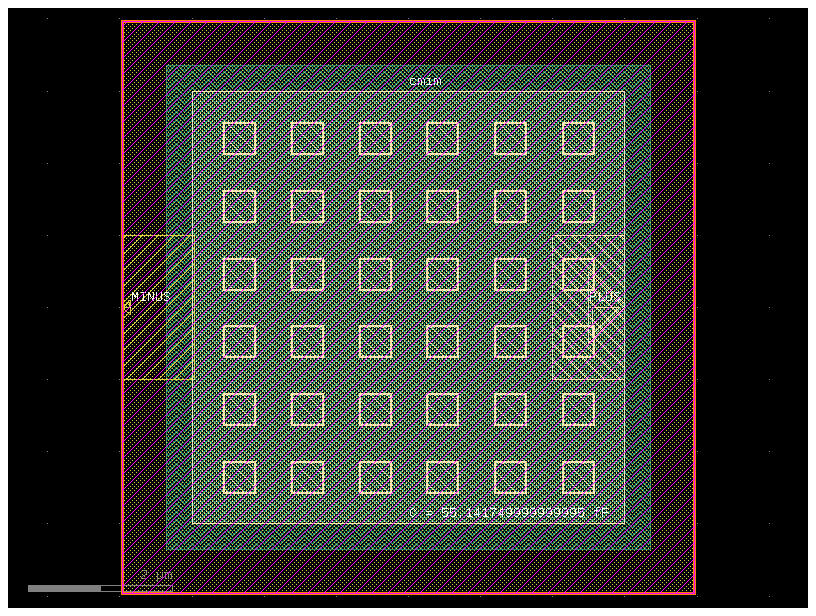

In [14]:
c = cmim(width=6.0, length=6.0)

cc = c.copy()
cc.draw_ports()

cc.plot()

In [15]:
c.ports

["Port(self.name='MINUS', self.width=200, trans=r180 *1 -3.86,0, layer=Metal5pin (67/2), port_type=electrical)", "Port(self.name='PLUS', self.width=1000, trans=r0 *1 2.5,0, layer=TopMetal1pin (126/2), port_type=electrical)"]

In [16]:
sim = DrivenSim()
sim.set_output_dir("../palace-sim-cmim")
sim.set_geometry(c)

sim.set_stack(yaml_path=yaml_file)

sim.add_port("PLUS",from_layer="metal5",to_layer="topmetal1",geometry="via",excited=True)
sim.add_port("MINUS",from_layer="metal5",to_layer="topmetal1",geometry="via",excited=False)

sim.set_driven(fmin=1e9, fmax=20e9, num_points=20)

print(sim.validate_config())

Validation: PASSED


In [17]:
sim.mesh(preset="fine")

Mesh Summary
Dimensions: 207.9 x 207.9 x 518.3 µm
Nodes:      1,309
Elements:   11,177
Tetrahedra: 7,087
Edge length: 0.01 - 126.85 µm
Quality:    0.482 (min: 0.001)
SICN:       0.522 (all valid)
----------------------------------------
Volumes (5):
  - air [1]
  - passive [2]
  - SiO2 [3]
  - silicon [4]
  - airbox [5]
Surfaces (8):
  - metal5_xy [6]
  - metal5_z [7]
  - topmetal1_xy [8]
  - topmetal1_z [9]
  - vmim_xy [10]
  - P1 [11]
  - P2 [12]
  - Absorbing_boundary [13]
----------------------------------------
Mesh:   ../palace-sim-cmim/palace.msh

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-10 12:47:47.504 (11710.926s) [    7993D1425080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-10 12:47:47.513 (11710.935s) [    7993D1425080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/card1: Permission denied

2026-03-10 12:47:47.550 (11710.972s) [    7993D1425080

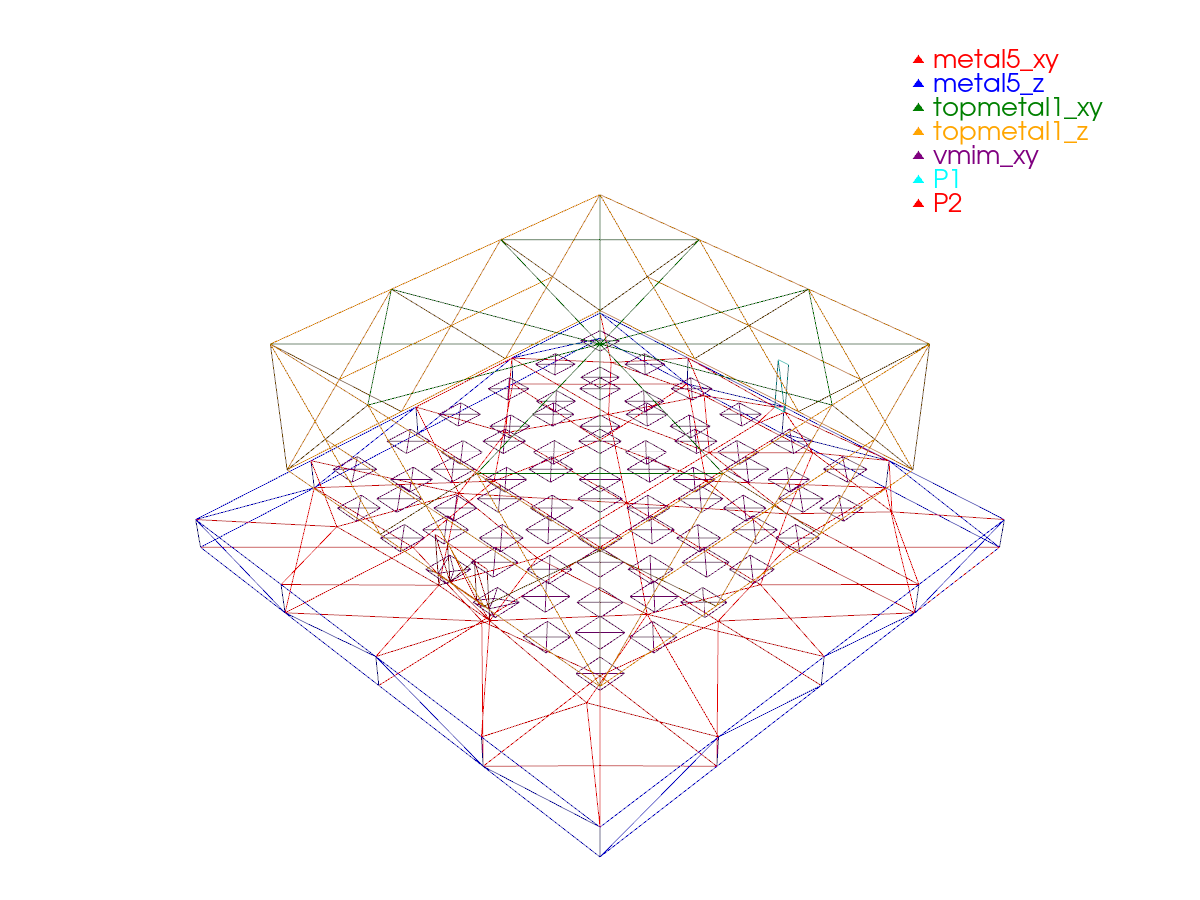

In [18]:
sim.plot_mesh(show_groups=["metal","vmim","P"], interactive=False)